## Lg Q Analysis
Finding event specific source term and Q

In [1]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
import random
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import csv
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm
from scipy.signal import resample
from obspy import Stream
from matplotlib.colors import LogNorm

import pandas as pd

from new_functions import *

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
import warnings
warnings.filterwarnings("ignore")

5.7


/home/schreinl/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
existent_catalog_with_coords = []

datacenters = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC','BGR',"http://fdsnws.sismologia.ign.es"]
directory = '/home/schreinl/Stage/Data1/'
distmin = 0.5
distmax = 10.0
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
#catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
eq_list = catalogue_5
codawindow = 'cutoff'
factor = 1.1
fmin = [0.5,2,4]
fmax = [1.5,3,6]
counter = 0

for event in range(len(eq_list)):
    #print("event", event, "out of", len(eq_list))
    start = UTCDateTime(eq_list["time"][event]) - 25
    end = start + 700
    eq_lon = float(eq_list["longitude"][event])
    eq_lat = float(eq_list["latitude"][event])
    
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    existent = True
    for i in range(len(fmin)):
        amplitude_test = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_new_{codawindow}_fac_{factor}_{fmin[i]}_{fmax[i]}Hz_dict.txt"
        if os.path.exists(amplitude_test):
            counter += 1
            if eq_list["time"][event] not in [entry[0] for entry in existent_catalog_with_coords]:
                existent_catalog_with_coords.append((eq_list["time"][event], eq_lat, eq_lon))
        else:
            existent = False

latitudes = [entry[1] for entry in existent_catalog_with_coords]
longitudes = [entry[2] for entry in existent_catalog_with_coords]

event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

for time, lat, lon in existent_catalog_with_coords:
    popup_text = f"Event Time: {time}<br>Lat: {lat}, Lon: {lon}"
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        tooltip=popup_text,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=1
    ).add_to(event_map)

event_map


#### Site term calculation

Here all the site terms are calculated, for different frequency bands, and one is plotted.

In [3]:
fmin = 2
fmax = 3
frequenciesmin = [0.5,2,4,6]
frequenciesmax = [1.5,3,6,8]
event_file='/home/schreinl/Stage/Data/big_box_4.5.csv'
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

#calculate the site terms 
dict_test = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", factor=1.1, fmin=fmin, fmax=fmax, data_dir='Data1',envelope_name='new')
ref_value_test = reference_stations_median(best_bet,event_file, fmin, fmax, envelope_name='new')
sites_effect_dict_test = site_effect_dict(event_file, fmin,fmax,best_bet,envelope_name='new')

site_effects = site_effect_overall(fmin,fmax,best_bet,frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax,method='multiple',map_plot=False,envelope_name='new')
carte = map_site_effect(fmin,fmax,site_effects,method='multiple')
carte

done reading in


In [4]:
#get the amplitudes of the Lg waves for all the frequency ranges

'''

from urllib.error import URLError
from http.client import HTTPException
import os
import warnings
warnings.filterwarnings("ignore")

datacenters = ['RESIF', 'ODC', 'ETH', 'INGV', 'GEOFON', 'IRIS', 'ICGC','BGR',"http://fdsnws.sismologia.ign.es"]
directory = '/home/schreinl/Stage/Data1/'
distmin = 0.5
distmax = 10.0
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
eq_list = catalogue_5
codawindow = 'cutoff'
factor = 1.1
fmin = [0.5,2,4]
fmax = [1.5,3,6]

for event in range(len(eq_list)):
    print("event", event, "out of", len(eq_list))
    start = UTCDateTime(eq_list["time"][event]) -25
    end = start + 700
    eq_lon = float(eq_list["longitude"][event])
    eq_lat = float(eq_list["latitude"][event])
    
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    for i in range(len(fmin)):
        retry_attempts = 3
        
        for attempt in range(retry_attempts):
            try:
                st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
                break
            except (URLError, FDSNNoDataException, HTTPException) as e:
                print(f"Failed to download data for event {event} on attempt {attempt + 1}: {str(e)}")
                if attempt < retry_attempts - 1:
                    print("Retrying with a smaller time window...")
                    end -= 100  # Reduce the time window by 100 seconds and retry
                else:
                    print("Max retry attempts reached. Skipping event...")
                    break  # Exit the retry loop and skip the event




    for i in range(len(fmin)):
        print(f'Frequency range {fmin[i]}-{fmax[i]}')
        
        st_plot_filt_all = st_all.copy()
        st_plot_filt_all.filter("bandpass", freqmin=fmin[i], freqmax=fmax[i])


        snr_threshold = 5
        eq_start = start

        filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_test, filtered_st, stations_with_amps, amp_plot = SNR_all(
            stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min, vLg_max, vPg_min, vPg_max, tminCoda, tmaxCoda,
            Dtmin_Noise, Dtmax_Noise, eq_start, eq_lat, eq_lon, snr_threshold=snr_threshold, plot_SNR=False, plot_amps=True, wavecode="Lg_Coda", dB=True, codawindow=codawindow, factor=factor)

        if filtered_stations_with_SNR is None or len(filtered_stations_with_SNR) == 0:
            continue
        
        with open(f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_{fmin[i]}_{fmax[i]}Hz_{snr_threshold}_thresh_stations_with_amps.txt", "w") as ampls:
            json.dump(stations_with_amps.tolist(), ampls, indent=4)
'''

'\n\nfrom urllib.error import URLError\nfrom http.client import HTTPException\nimport os\nimport warnings\nwarnings.filterwarnings("ignore")\n\ndatacenters = [\'RESIF\', \'ODC\', \'ETH\', \'INGV\', \'GEOFON\', \'IRIS\', \'ICGC\',\'BGR\',"http://fdsnws.sismologia.ign.es"]\ndirectory = \'/home/schreinl/Stage/Data1/\'\ndistmin = 0.5\ndistmax = 10.0\ncatalogue_5 = pd.read_csv(\'/home/schreinl/Stage/Data/big_box_4.5.csv\')\neq_list = catalogue_5\ncodawindow = \'cutoff\'\nfactor = 1.1\nfmin = [0.5,2,4]\nfmax = [1.5,3,6]\n\nfor event in range(len(eq_list)):\n    print("event", event, "out of", len(eq_list))\n    start = UTCDateTime(eq_list["time"][event]) -25\n    end = start + 700\n    eq_lon = float(eq_list["longitude"][event])\n    eq_lat = float(eq_list["latitude"][event])\n    \n    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")\n    for i in range(len(fmin)):\n        retry_attempts = 3\n        \n        for attempt in range(retry_attempts):\n            try:\n  

#### Calculation of the Lg Amplitude of each seismogram for each event

In [5]:




def Lg_amplitude_dict(base_directory):
    events_data = {}

    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)

        if os.path.isdir(dir_path):
            event_stations = {} 
            for filename in os.listdir(dir_path):
                if filename.endswith("_5_thresh_stations_with_amps.txt"):
                    file_path = os.path.join(dir_path, filename)

                    with open(file_path, "r") as f:
                        data = json.load(f)

                    for entry in data:
                        network = entry[0]
                        station_name = entry[1]
                        amplitude = float(entry[12])
                        station_key = f"{network}.{station_name}"
                        event_stations[station_key] = amplitude

            events_data[timestamp_dir] = event_stations

    return events_data

base_directory = "/home/schreinl/Stage/Data1" 
Lg_dict = Lg_amplitude_dict(base_directory)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")






Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [6]:
import os
import json

def Lg_amplitude_dict(base_directory):
    events_data = {}

    for timestamp_dir in sorted(os.listdir(base_directory)):
        dir_path = os.path.join(base_directory, timestamp_dir)

        if os.path.isdir(dir_path):
            event_stations = {} 
            for filename in os.listdir(dir_path):
                if filename.endswith("_5_thresh_stations_with_amps.txt"):
                    file_path = os.path.join(dir_path, filename)

                    with open(file_path, "r") as f:
                        data = json.load(f)

                    # Filter out any unwanted keys like "Dicts" or "Metadata"
                    if isinstance(data, dict):
                        # Only extract the relevant part, assuming the station data is the list
                        # and it's contained in the expected key. You might need to adjust
                        # this based on your JSON structure.
                        if "stations" in data:
                            data = data["stations"]  # Replace "stations" with correct key if necessary
                        else:
                            data = []

                    # Now process the relevant station data
                    if isinstance(data, list):
                        for entry in data:
                            if isinstance(entry, list) and len(entry) > 12:
                                network = entry[0]
                                station_name = entry[1]
                                amplitude = float(entry[12])
                                station_key = f"{network}.{station_name}"
                                event_stations[station_key] = amplitude

            events_data[timestamp_dir] = event_stations

    return events_data

base_directory = "/home/schreinl/Stage/Data1" 
Lg_dict = Lg_amplitude_dict(base_directory)

output_path = "/home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt"
with open(output_path, "w") as f:
    json.dump(Lg_dict, f, indent=4)

print(f"Extracted data saved to {output_path}")


Extracted data saved to /home/schreinl/Stage/Data1/Lg_Amplitudes_all_events.txt


In [7]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c 


# ln(A*r**0.83) - ln(Siteeffect) = ln(Sk) - pi*f*r/Q*V
#f being the center frequency, V the velocity of the Lg wave which can be taken as 3.1km/s
#create a dict that has for each event the amplitude of the Lg wave window for each station 




def Lg_amplitude_calculation(fmin,fmax,Lg_dict,savefile=False):


    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)


    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))

    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)

    results = {}
    Q0_calculation_terms = {}

    for event_time, stations in Lg_dict.items():
        if event_time in ["Dicts", "Metadata"]: 
            continue
        
        formatted_event_time = (UTCDateTime(event_time) + 25).strftime("%Y_%m_%dT%H_%M_%S")
        #print(formatted_event_time)
        if formatted_event_time not in event_data:
            #print(f"Skipping event {formatted_event_time}: Not found in CSV")
            continue
        
        event_lat, event_lon = event_data[formatted_event_time]
        event_results = {}
        tmp = {}
        for station, amplitude in stations.items():
            if station not in station_coords:
                continue
            
            lat, lon = station_coords[station]
            r = haversine(event_lat, event_lon, lat, lon)

            site_effect = None
            for freq_band, site_info in site_terms.items():
                freq_min, freq_max = map(lambda x: float(x.replace('Hz', '').strip()), freq_band.split('-'))
                
                if fmin <= freq_min <= fmax and fmax >= freq_max >= fmin:
                    if station.split(".")[1] in site_info:
                        site_effect = site_info[station.split(".")[1]].get("median_after", None)
                        break
            
            if site_effect is None or site_effect <= 0:
                continue 
            #log_value = np.log(amplitude * (r ** 0.83)) - np.log(site_effect)
            log_value = np.log(amplitude) + (5/6)*np.log(r) - np.log(site_effect)
            event_results[station] = {"log_value": log_value, "distance_km": r}
            tmp[station] = {'amplitude': amplitude, 'distance': r, 'site_effect': site_effect}
        results[formatted_event_time] = event_results
        Q0_calculation_terms[formatted_event_time] = tmp

    results_with_coords = {}
    for event_time, event_results in results.items():
        event_lat, event_lon = event_data[event_time]
        results_with_coords[event_time] = {
            "coordinates": {"latitude": event_lat, "longitude": event_lon},
            "data": event_results
        }
    if savefile:
        with open("../Data1/processed_event_amplitudes.txt", "w") as f:
            json.dump(results, f, indent=4)
        with open("../Data1/orocessed_event_amplitudes_coords.txt", "w") as g:
            json.dump(results_with_coords, g, indent=4)

    print("Processing complete.")
    return results, results_with_coords

In [8]:
base_directory = "/home/schreinl/Stage/Data1" 
Lg_dict = Lg_amplitude_dict(base_directory)
results , results_with_coords= Lg_amplitude_calculation(fmin,fmax,Lg_dict,savefile=True)



Processing complete.


Intercept: -9.50439258798068
Slope: -0.006091903983763094
for event 2008_12_23T15_24_22 the Q factor is 402.89033890861026


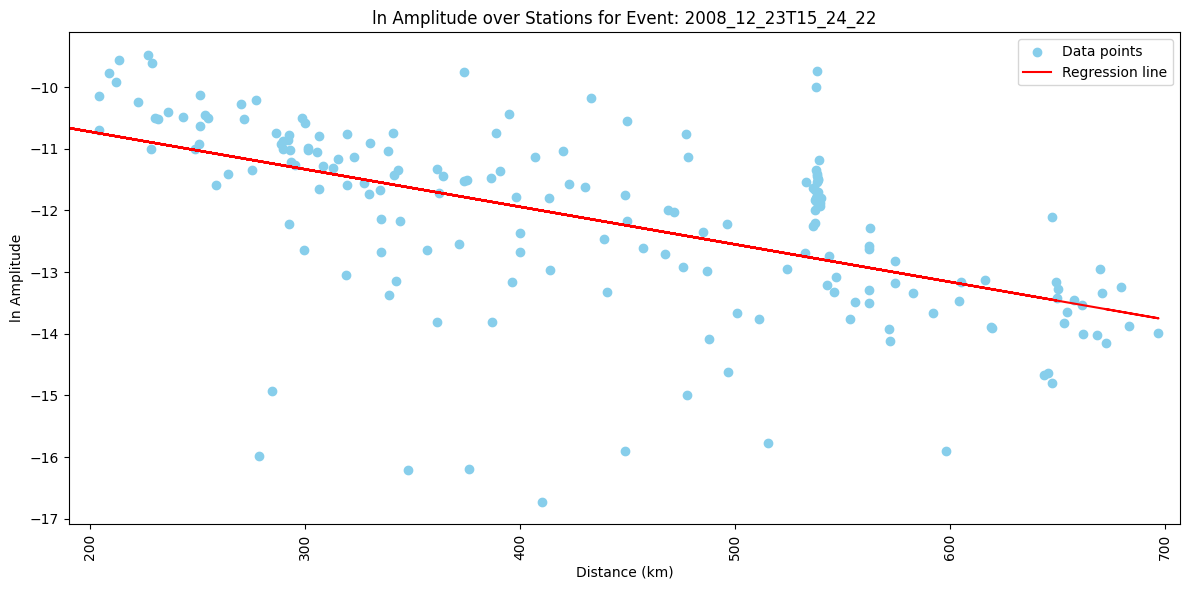

In [9]:
from scipy.stats import linregress
#event_time =  '2023_06_16T16_38_28'#  '2022_11_09T06_07_26'

event_time = list(results.keys())[10] 
event_data = results[event_time]

stations = list(event_data.keys())
log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
distances = [station_data["distance_km"] for station_data in event_data.values()]

filtered_distances = [d for d in distances if d > 200]
filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")
Q = -(np.pi*((fmin+fmax)/2)/(3.2*slope) )
print(f'for event {event_time} the Q factor is {Q}')
plt.figure(figsize=(12, 6))
plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
plt.plot(distances, intercept + slope * np.array(distances), color='red', label='Regression line')
plt.xlabel('Distance (km)')
plt.ylabel('ln Amplitude')
plt.xlim([190,max(filtered_distances)+10])
plt.title(f'ln Amplitude over Stations for Event: {event_time}')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



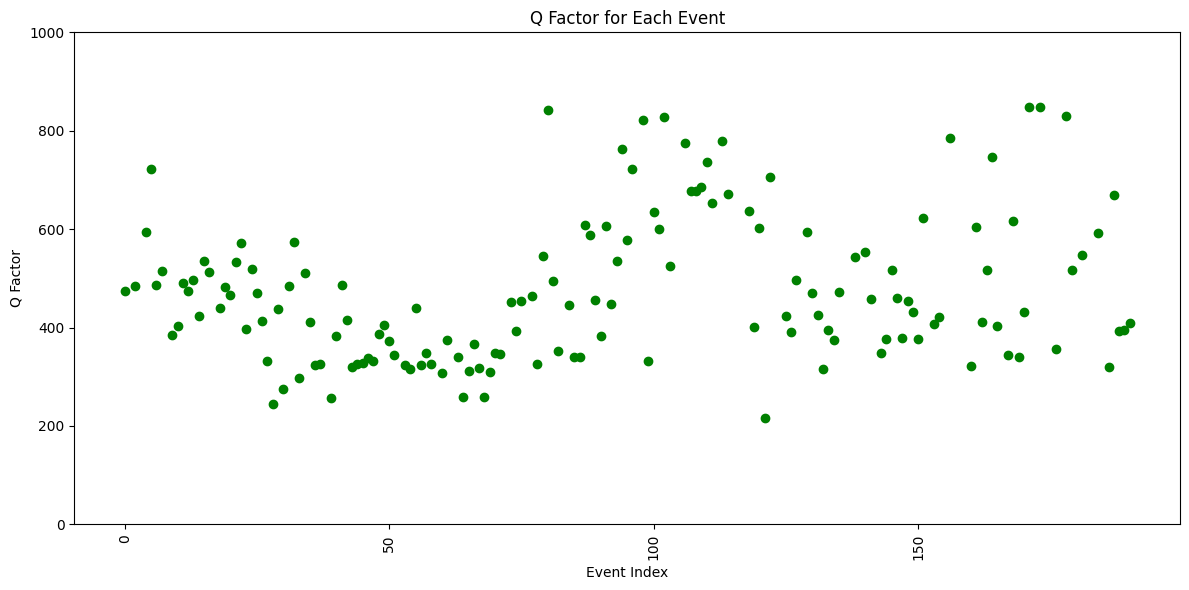

In [10]:


Q_values = {}

for event_time, event_data in results.items():
    stations = list(event_data.keys())
    log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
    distances = [station_data["distance_km"] for station_data in event_data.values()]

    # Filter out distance values less than or equal to 200 km
    filtered_distances = [d for d in distances if d > 200]
    filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

    if len(filtered_distances) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(filtered_distances, filtered_log_amplitudes)

        Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope))

        Q_values[event_time] = Q
        #this can be sometimes
        #plt.scatter(filtered_distances, filtered_log_amplitudes, color='skyblue', label='Data points')
        #plt.plot(filtered_distances, intercept + slope * np.array(filtered_distances), color='red', label='Regression line')
        #plt.xlabel('Distance (km)')
        #plt.ylabel('ln Amplitude')
        #plt.title(f'ln Amplitude over Stations for Event: {event_time}')
        #plt.legend()
        #plt.xticks(rotation=90)
        #plt.tight_layout()
        #plt.show()
plt.figure(figsize=(12, 6))
plt.scatter(range(len(Q_values)), list(Q_values.values()), marker='o', color='green')
plt.xlabel('Event Index')
plt.ylim([0,1000])
plt.ylabel('Q Factor')
plt.title('Q Factor for Each Event')
plt.xticks(range(0, len(Q_values), 50), rotation=90)
plt.tight_layout()
plt.show()

#for event_time, Q in Q_values.items():
#    print(f"Event Time: {event_time}, Q: {Q}")


Processing complete.
Processed 191 events with Q0 and Sk values.


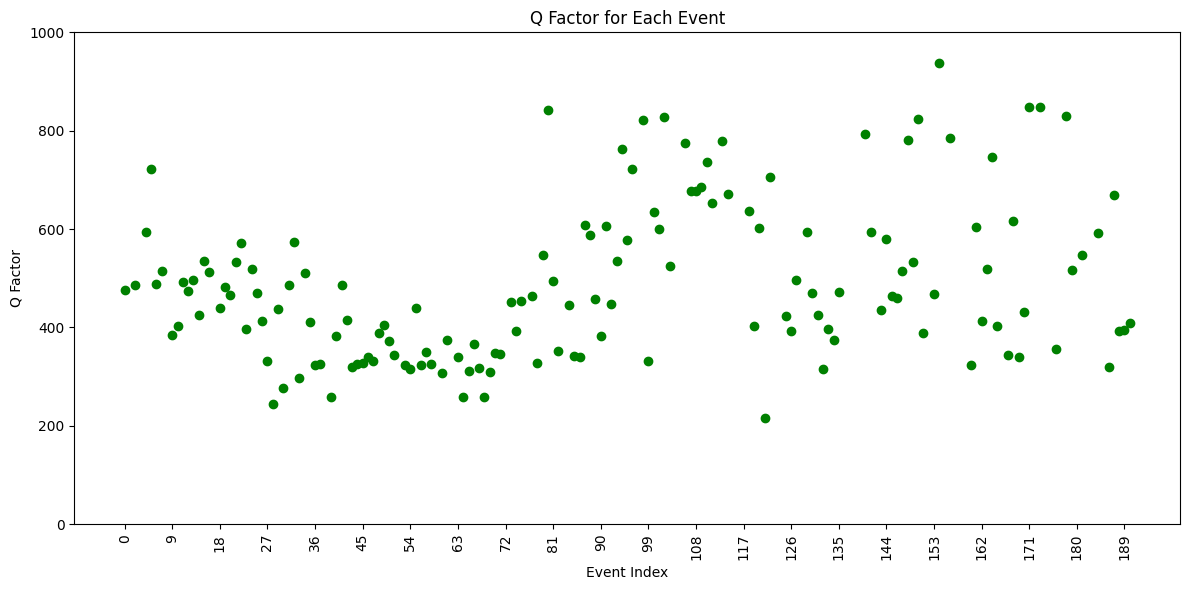

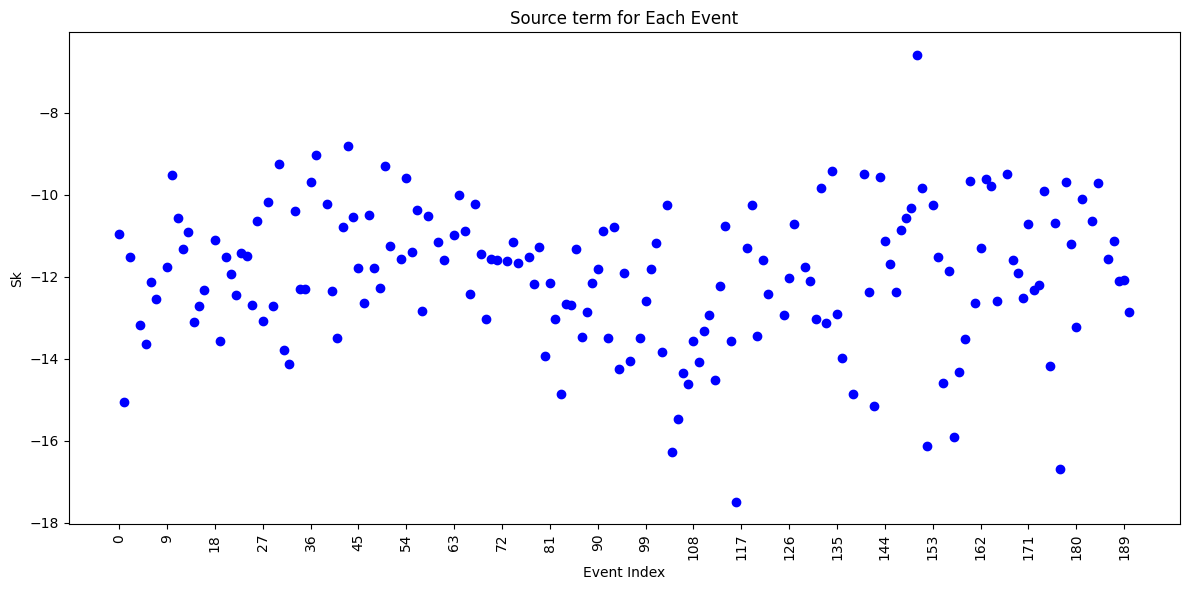

In [25]:
def Lg_Q0_Sk(fmin, fmax, plot_Q0=False, plot_Sk=False):
    base_directory = "/home/schreinl/Stage/Data1" 
    Lg_dict = Lg_amplitude_dict(base_directory)
    results, results_with_coords = Lg_amplitude_calculation(fmin, fmax, Lg_dict, savefile=False)

    event_data_dict = {}

    for event_time, event_data in results.items():
        log_amplitudes = [station_data["log_value"] for station_data in event_data.values()]
        distances = [station_data["distance_km"] for station_data in event_data.values()]

        filtered_distances = [d for d in distances if d > 200]
        filtered_log_amplitudes = [log_amplitudes[i] for i in range(len(distances)) if distances[i] > 200]

        if len(filtered_distances) > 1:
            slope, intercept, _, _, _ = linregress(filtered_distances, filtered_log_amplitudes)
            Q = -(np.pi * ((fmin + fmax) / 2) / (3.2 * slope))

            if event_time in results_with_coords:
                coordinates = results_with_coords[event_time]["coordinates"]
                event_data_dict[event_time] = {
                    "Q0": Q,
                    "Sk": intercept,
                    "coordinates": coordinates
                }

    print(f"Processed {len(event_data_dict)} events with Q0 and Sk values.")

    if plot_Q0 and event_data_dict:
        Q0_values = [data["Q0"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Q0_values)), Q0_values, marker='o', color='green')
        plt.xlabel('Event Index')
        plt.ylim([0, 1000])
        plt.ylabel('Q Factor')
        plt.title('Q Factor for Each Event')
        plt.xticks(range(0, len(Q0_values), max(1, len(Q0_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    if plot_Sk and event_data_dict:
        Sk_values = [data["Sk"] for data in event_data_dict.values()]
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(Sk_values)), Sk_values, marker='o', color='blue')
        plt.xlabel('Event Index')
        plt.ylabel('Sk')
        plt.title('Source term for Each Event')
        plt.xticks(range(0, len(Sk_values), max(1, len(Sk_values)//20)), rotation=90)
        plt.tight_layout()
        plt.show()

    return event_data_dict

Q0_Sk_dict = Lg_Q0_Sk(2, 3, plot_Q0=True, plot_Sk=True)

#fmins = [0.5,2,4,6]
#fmaxs = [1.5,3,6,8]
#Q_mean = {}
#for mini, maxi in zip(fmins,fmaxs):
#    fcenter = (mini+maxi)/2
#    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
#    test_Q0, test_Sk = Lg_Q0_Sk(mini, maxi, plot_Q0=True, plot_Sk=False)
#    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(list(test_Q0.values()))}



In [ ]:
Q0_Sk_dict = Lg_Q0_Sk(2, 3, plot_Q0=False, plot_Sk=False)


latitudes = [event_data['coordinates']["latitude"] for event_data in Q0_Sk_dict.values()]
longitudes = [event_data['coordinates']["longitude"] for event_data in Q0_Sk_dict.values()]
Q_values = [event_data["Q0"] for event_data in Q0_Sk_dict.values()]

unique_Q_values = sorted(set(Q for Q in Q_values if not np.isnan(Q)))

colormap = cm.LinearColormap(
    colors=["blue", "green", "yellow", "orange", "red"], 
    vmin=80, 
    vmax=550
)
colormap.caption = "Q Factor"

event_map = folium.Map(location=[np.mean(latitudes), np.mean(longitudes)], zoom_start=5, tiles="OpenStreetMap")

counter = 0
for event_time, event_data in Q0_Sk_dict.items():
    Q = event_data["Q0"]
    lat = event_data['coordinates']["latitude"]
    lon = event_data['coordinates']["longitude"]
    
    if not np.isnan(Q):
        counter += 1
        popup_text = f"Event: {event_time}<br>Q: {Q:.2f}"
        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            tooltip=popup_text,
            color=colormap(Q),  # Use colormap with sorted values
            weight=1,
            fill=True,
            fill_color=colormap(Q),
            fill_opacity=0.9
        ).add_to(event_map)

colormap.add_to(event_map)
print(f'{counter} events on map')
event_map


Processing complete.
Processed 191 events with Q0 and Sk values.
172 events on map


### Frequency dependency of Q



We measure the attenuation factor Q as well as the source term for each event, based on the natural logarithm of the amplitudes of the Lg wave corrected by the geometry factor as well as the site term. 
This corrected amplitude is then plotted over the event-station distance, and a linear regression is done to find the parameters of the distribution. The intercept in this case corresponds to the source term while the slope corresponds to the attenuation factor Q.

In [13]:
fmins = [0.5,2,4,6]
fmaxs = [1.5,3,6,8]
Q_mean = {}
for mini, maxi in zip(fmins,fmaxs):
    fcenter = (mini+maxi)/2
    print(f'frequency range {mini}-{maxi} with center frequency {fcenter}')
    test_Q0, test_Sk = Lg_Q0_Sk(mini, maxi, plot_Q0=False, plot_Sk=False)
    Q_mean[f'{fcenter} Hz'] = {"Q_mean": np.nanmedian(list(test_Q0.values()))}

frequency range 0.5-1.5 with center frequency 1.0
Processing complete.
Processing complete.
Q0_values has 191 entries.
Sk_values has 191 entries.
frequency range 2-3 with center frequency 2.5
Processing complete.
Processing complete.
Q0_values has 191 entries.
Sk_values has 191 entries.
frequency range 4-6 with center frequency 5.0
Processing complete.
Processing complete.
Q0_values has 191 entries.
Sk_values has 191 entries.
frequency range 6-8 with center frequency 7.0
Processing complete.
Processing complete.
Q0_values has 191 entries.
Sk_values has 191 entries.


#### Finding path specific Q

$$ \ln(A_{k,l} \cdot r^{0.83}) - \ln(P(f)) = \ln(S_k) - \frac{\pi \cdot f \cdot r}{Q \cdot V} $$
which has to be rewritten to find $$ Q_{k,l} $$, which is possible due to all the other terms being known. 

In [26]:
def Q_kl(fmin,fmax):


    event_data = {}
    with open("../Data/big_box_4.5.csv", "r") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            event_time = UTCDateTime(row[0])
            event_lat = float(row[1])
            event_lon = float(row[2])
            
            event_time_str = event_time.strftime("%Y_%m_%dT%H_%M_%S")
            event_data[event_time_str] = (event_lat, event_lon)
    
    with open("../Data1/Site_effects_dict.txt", "r") as f:
        site_terms = json.load(f)



    station_coords = {}
    with open("../Data1/all_stations_coordinates.txt", "r") as f:
        next(f)
        for line in f:
            if line.strip():
                network, station, lat, lon = line.strip().split(",")
                station_coords[f"{network}.{station}"] = (float(lat), float(lon))
    Q0_Sk_dict = Lg_Q0_Sk(fmin, fmax)



    
    




    